# Applying TF-IDF and Sentiment Valence

In this notebook, in general we treat one issue with all its comments as a document, and one repository as a corpus. Lateron we will merge all the corpa to gain one big ""Github corpus", we can then categories our repos as communities, which we can then do analysis on.   
We compute TF-IDF and sentiment valence, and then analyze issues and repositories.


## Imports

In [123]:
import math
import re
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from scipy.stats import ttest_ind


## Pre-processing the data

Pre-process the data, takes in all the .txt files from all repo's and turns them into a pre-processed .csv file containing all the text per issue.

#### Loading the TXT data into pandas dataframes

In [99]:
def load_txt_data(data_path: str, repo_name: str):
    rows = []

    f =  open(data_path, "r", encoding="utf-8")
    lines = f.read().splitlines()

    f.close()

    i = 0
    issue_id = 0
    n = len(lines)
    current_issue_opener = None

    while i < n:
        line = lines[i]
        # If the text is an issue.
        if line.startswith("issue:"):
            issue_id += 1

            opener = line[len("issue:"):]
            issue_type = lines[i + 1]
            date = lines[i + 2]
            title = lines[i + 3]
            body = lines[i + 4]

            current_issue_opener = opener

            rows.append({
                "type": "issue",
                "issue_type": (issue_type if issue_type else "N/A"),
                "issue_date": date,
                "opener": opener,
                "title": title,
                "body": body,
                # issues are opened by the opener, put it in commenter column for easy comparison
                "commenter": opener,
                "issue_id": f"{repo_name}-{issue_id}"
            })

            i += 5
            continue
        # If the text is a comment.
        if line.startswith("comment:"):
            commenter = line[len("comment:"):]
            body = lines[i + 1]

            rows.append({
                "type": "comment",
                "opener": current_issue_opener,
                "title": None,
                "body": body,
                "commenter": commenter,
                "issue_id": f"{repo_name}-{issue_id}"
            })

            i += 2
            continue

        i += 1
    df = pd.DataFrame(rows)
    return df

In [100]:
data_paths = ["raw_data_networkx.txt", "raw_data_pandas.txt", "raw_data_tensorflow.txt"]

# Individual dataframes
df_nx = load_txt_data(data_paths[0], "nx")
df_pd = load_txt_data(data_paths[1], "pd")
df_tf = load_txt_data(data_paths[2], "tf")

#### Merging all the dataframes into one big, pre-processed dataframe

In [101]:
def combine_issue_comments(df):
    rows = []

    grouped_per_issue = df.groupby("issue_id")
    for issue_id, group in grouped_per_issue:

        # take the text from the issue
        issue_row = group[group["type"] == "issue"].iloc[0]
        issue_text = issue_row["title"] + "\n" + issue_row["body"]

        # take the text from the comments
        comments = group[group["type"] == "comment"]
        comments_text = "\n".join(comments["body"].tolist())

        # combine issue text and comments text
        full_text = issue_text + " " + comments_text

        rows.append({"issue_id": issue_id, "full_text": full_text})

    return pd.DataFrame(rows)

In [102]:
nx_text_per_issue = combine_issue_comments(df_nx)
pd_text_per_issue = combine_issue_comments(df_pd)
tf_text_per_issue = combine_issue_comments(df_tf)

print(f"""Number of issues in 
      NetworkX dataset: {len(nx_text_per_issue)}
      Pandas dataset: {len(pd_text_per_issue)}
      TensorFlow dataset: {len(tf_text_per_issue)}""")

Number of issues in 
      NetworkX dataset: 3131
      Pandas dataset: 23662
      TensorFlow dataset: 39465


#### Actually pre-process the text

In [103]:
regex_textfilter = re.compile(r"[a-zA-Z']+")

github_and_general_stopwords = {
    "actually","basically","usually","probably","maybe","somehow","someone",
    "something","anyone","everyone","hi","hello","hey","please","kind",
    "kindof","kinda","sort","sorta","anyway","usecase","usecases","stuff",
    "things","thing","stufflike","thingy","etc","etcetera","btw","currently",
    "previously","literally","essentially","generally","typically","honestly",
    "technically","again","already","still","quite","very","really","just",
    "though","however","meanwhile","from","original","ticket","comment",
    "in","issue", "issues", "the","a","an","and","or","but","if","then","else","when","while","for",
    "of","in","on","at","to","from","by","with","about","into","over","after",
    "before","between","through","during","above","below","up","down","out",
    "off","under","again","further","once","here","there","where","why","how",
    "all","any","both","each","few","more","most","other","some","such","no",
    "nor","not","only","own","same","so","than","too","very","can","will",
    "just","is","am","are","was","were","be","being","been","do","does","did",
    "has","have","had","it","its","this","that","these","those","he","him",
    "his","she","her","they","them","their","we","us","our","you","your","i",
    "me","my", "nan"
} # this list includes standard stopwords along some github specific ones like issue, comment tickset and other stuff

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()
    tokens = regex_textfilter.findall(text)
    if len(tokens) <= 10:
        return ""

    cleaned = []
    for w in tokens:
        if w in github_and_general_stopwords:
            continue
        if len(w) == 1:
            continue
        cleaned.append(w)

    return " ".join(cleaned)


# quick sanity check, see if it works
preprocess_text("""tf.clip_by_value crashed on empty tensor (GPU) -- system information inside nan""")


'tf clip value crashed empty tensor gpu system information inside'

In [104]:
nx_preprocessed_text = nx_text_per_issue.assign(
    clean_text = nx_text_per_issue.full_text.apply(preprocess_text),
    repo_name = "networkx")

pd_preprocessed_text = pd_text_per_issue.assign(
    clean_text = pd_text_per_issue.full_text.apply(preprocess_text),
    repo_name = "pandas")

tf_preprocessed_text = tf_text_per_issue.assign(
    clean_text = tf_text_per_issue.full_text.apply(preprocess_text),
    repo_name = "tensorflow")

tf_preprocessed_text.head()

,issue_id,full_text,clean_text,repo_name
0,tf-1,Add support for Python 3.x\nCurrently we only ...,add support python support python should suppo...,tensorflow
1,tf-10,"Go API\nHi!, I'm really interested on contribu...",go api i'm interested contribute spare time pr...,tensorflow
2,tf-100,"TensorBoard logdir path, if relative, is relat...",tensorboard logdir path relative relative home...,tensorflow
3,tf-1000,tf.nn.xw_plus_b not in API docs \nThe method t...,tf nn xw plus api docs method tensorflow nn xw...,tensorflow
4,tf-10000,df982b8de - Split gpu_id.h and GpuIdManager ou...,df de split gpu id gpuidmanager build target b...,tensorflow


#### Merge dataframes and save as .csv

In [105]:
# merge dataframes and save as .csv
all_preprocessed = pd.concat(
    [nx_preprocessed_text, pd_preprocessed_text, tf_preprocessed_text],
    ignore_index=True)

all_preprocessed.to_csv("preprocessed_issues_comments.csv", index=False)

## Load the issue data

In [106]:
DATA_PATH = "preprocessed_issues_comments.csv"

all_df_processed = pd.read_csv(DATA_PATH)
all_df_processed.head()


,issue_id,full_text,clean_text,repo_name
0,nx-1,adding self loop should add node (migrated fr...,adding self loop should add node migrated trac...,networkx
1,nx-10,examples should fail gracefully (migrated from...,examples should fail gracefully migrated trac ...,networkx
2,nx-100,empty nodelist to draw_networkx_nodes raises a...,empty nodelist draw networkx nodes raises exce...,networkx
3,nx-1000,"problem in spring layout\nHi, I want to report...",problem spring layout want report problem spri...,networkx
4,nx-1001,networkx.info() can't handle directed networkx...,networkx info can't handle directed networkx i...,networkx


## Load LabMT / hedonometer data

load valence scores and standard deviations for sentiment weighting

#### If we want to use LabMT, run this Cell, otherwise run the next one

In [107]:
HEDONOMETER_PATH = "Hedonometer.csv"

hed_df = pd.read_csv(HEDONOMETER_PATH, sep=",", header=None,
                     names=["Rank", "Word", "English", "HS", "STD"])

hed_df["Word"] = hed_df["Word"].astype(str).str.lower()

hedonometer_dict = dict(zip(hed_df["Word"], hed_df["HS"]))
hed_sd_dict = dict(zip(hed_df["Word"], hed_df["STD"]))

len(hedonometer_dict), list(hedonometer_dict.items())[:5]


(10187,
 [('word', '5.56'),
  ('laughter', '8.5'),
  ('happiness', '8.44'),
  ('love', '8.42'),
  ('happy', '8.3')])

#### Code for enabling AFINN valence DB

to use the AFINN valence database, uncomment this code

In [108]:
# AFINN_PATH = "AFINN.txt"

# afinn_df = pd.read_csv(
#     AFINN_PATH,
#     sep="\t",
#     header=None,
#     names=["Word", "HS"]
# )

# afinn_df["Word"] = afinn_df["Word"].astype(str).str.lower()

# hedonometer_dict = dict(zip(afinn_df["Word"], afinn_df["HS"]))

# hed_sd_dict = defaultdict(lambda: 1.0)

# len(hedonometer_dict), list(hedonometer_dict.items())[:5]


## Compute per-issue term frequencies and global document frequencies

for each issue, we build a term-frequency dict, from all issues we derive document frequencies for IDF.

In [109]:
term_freqs_per_issue = {}            # issue_id -> {term: count}
doc_freqs = defaultdict(int)         # term -> number of documents containing it

# Decide which column acts as issue id; we use the DataFrame index by default.
issue_ids = all_df_processed["issue_id"]
all_df_processed = all_df_processed.set_index("issue_id")

for issue_id in tqdm(issue_ids, desc="Building term frequencies"):
    text = all_df_processed.loc[issue_id, "clean_text"]

    text = str(text)              # safe cast
    tokens = text.split()         # split into words

    if not tokens:
        continue

    tf = defaultdict(int)
    for t in tokens:
        tf[t] += 1

    term_freqs_per_issue[issue_id] = dict(tf)

    for t in tf.keys():
        doc_freqs[t] += 1


num_docs = len(term_freqs_per_issue)
num_docs, len(doc_freqs)


Building term frequencies: 100%|██████████| 66258/66258 [00:27<00:00, 2422.96it/s]


(66258, 252036)

## Compute IDF by hand

Use a standard log-based IDF

In [110]:
idf = {}
epsilon = 1e-9

for term, df in doc_freqs.items():
    # Classic IDF; +epsilon just in case
    idf[term] = math.log((num_docs + epsilon) / (df + epsilon))

# Inspect a few sample IDF scores
list(idf.items())[:10]


[('adding', 1.9637568890245634),
 ('self', 1.5547131913544836),
 ('loop', 2.953733755073141),
 ('should', 0.7434734329010663),
 ('add', 1.3895899543609667),
 ('node', 2.1903209966183463),
 ('migrated', 4.252245208640683),
 ('trac', 4.475919123265919),
 ('https', 0.26575828774953597),
 ('networkx', 3.1600159203683136)]

## Compute TF-IDF per issue manually

For each issue, compute normalized tf and multiply by idf.

In [111]:
tfidf_per_issue = {}   # issue_id -> {term: tf-idf}

for issue_id, tf_dict in tqdm(term_freqs_per_issue.items(), desc="Computing TF-IDF per issue"):
    total_terms = sum(tf_dict.values())
    if total_terms == 0:
        continue

    tfidf = {}
    for term, count in tf_dict.items():
        if term not in idf:
            continue
        tf = count / total_terms          # length-normalized TF
        tfidf[term] = tf * idf[term]

    if tfidf:
        tfidf_per_issue[issue_id] = tfidf

len(tfidf_per_issue)


Computing TF-IDF per issue: 100%|██████████| 66258/66258 [00:09<00:00, 7244.55it/s] 


66258

## Compute sentiment valence with improved weighting

In [112]:
def compute_issue_valence(tf_dict, hedonometer_dict, sd_dict, min_count=1, epsilon=1e-6):
    """Compute a reliability-weighted, length-invariant valence score for one issue."""
    total_terms = sum(tf_dict.values())
    if total_terms == 0:
        return None

    num = 0.0
    denom = 0.0

    for term, count in tf_dict.items():
        if count < min_count:
            continue
        if term not in hedonometer_dict:
            continue

        v = float(hedonometer_dict[term])
        sigma = float(sd_dict[term])

        p = count / total_terms
        reliability = 1.0 / (sigma * sigma + epsilon)
        weight = p * reliability

        num += weight * v
        denom += weight

    if denom == 0.0:
        return None

    return num / denom

issue_valence = {}
for issue_id, tf_dict in tqdm(term_freqs_per_issue.items(), desc="Computing issue valence"):
    val = compute_issue_valence(tf_dict, hedonometer_dict, hed_sd_dict)
    issue_valence[issue_id] = val

valence_series = pd.Series(issue_valence, name="valence")
valence_series.describe()


Computing issue valence: 100%|██████████| 66258/66258 [00:08<00:00, 7974.04it/s] 


count    66185.000000
mean         5.405959
std          0.160072
min          3.145673
25%          5.317410
50%          5.419994
75%          5.507231
max          6.919103
Name: valence, dtype: float64

## Visualize distribution of valence scores

Plot a histogram of issue-level valence to see overall sentiment spread.

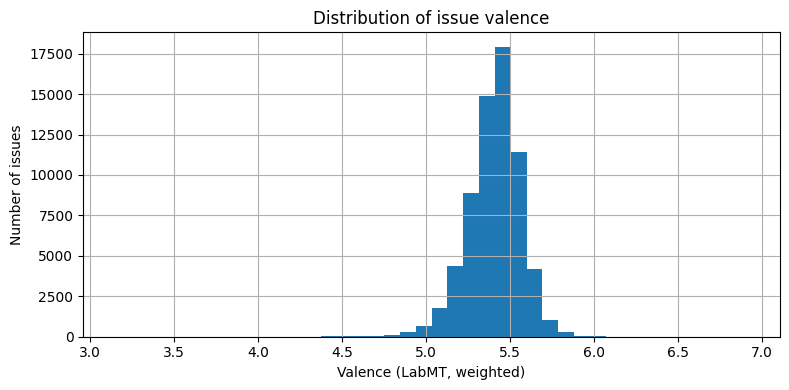

In [113]:
plt.figure(figsize=(8, 4))
valence_series.dropna().hist(bins=40)
plt.xlabel("Valence (LabMT, weighted)")
plt.ylabel("Number of issues")
plt.title("Distribution of issue valence")
plt.tight_layout()
plt.show()


## Top and bottom issues by valence

Identify the most positive and most negative issues according to the weighted valence.

Top 10 issues by valence:
 pd-21029    6.919103
tf-24225    6.495017
pd-1389     6.460764
pd-436      6.286351
tf-15015    6.160378
pd-1653     6.129283
tf-2009     6.124235
tf-3114     6.094363
pd-734      6.090687
tf-7406     6.089988
Name: valence, dtype: float64

Bottom 10 issues by valence:
 tf-6842     3.145673
tf-39347    3.252404
pd-16499    3.763957
pd-13128    3.765506
pd-18788    3.794114
pd-2462     3.829967
pd-4228     3.993339
pd-17013    4.038590
pd-840      4.043832
tf-38442    4.075091
Name: valence, dtype: float64


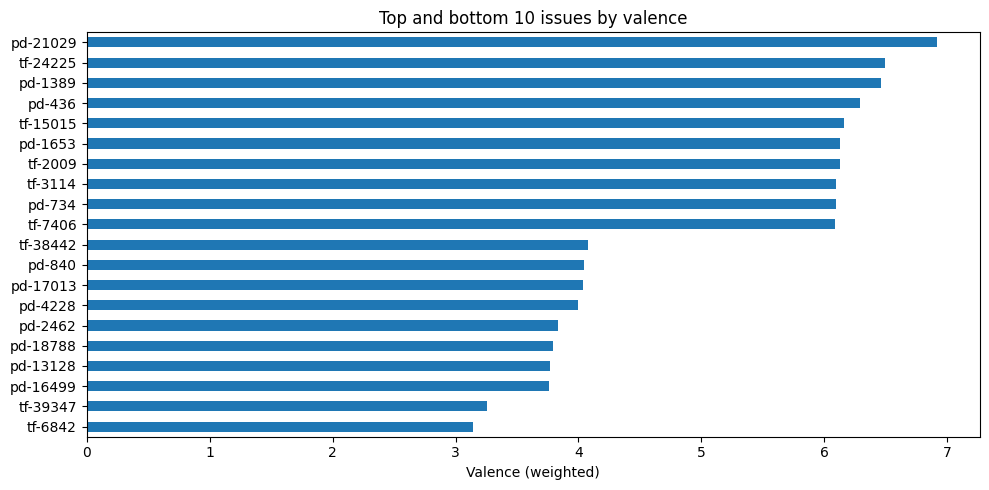

In [114]:
top_10 = valence_series.dropna().nlargest(10)
bottom_10 = valence_series.dropna().nsmallest(10)

print("Top 10 issues by valence:\n", top_10)
print("\nBottom 10 issues by valence:\n", bottom_10)

viz_data = pd.concat([top_10, bottom_10])
plt.figure(figsize=(10, 5))
viz_data.sort_values().plot(kind="barh")
plt.xlabel("Valence (weighted)")
plt.title("Top and bottom 10 issues by valence")
plt.tight_layout()
plt.show()


## Top TF-IDF terms for the highest-valence issue

Inspect which terms dominate the most positive issue according to TF-IDF.


=== Top 1 Issue ===
Issue ID: pd-21029
Valence: 6.919

Issue text:
BUG: len(map)
### Pandas version checks  - [X] I have checked that this issue has not already been reported.  - [X] I have confirmed this bug exists on the [latest version](https://pandas.pydata.org/docs/whatsnew/index.html) of pandas.  - [X] I have confirmed this bug exists on the [main branch](https://pandas.pydata.org/docs/dev/getting_started/install.html#installing-the-development-version-of-pandas) of pandas.   ### Reproducible Example  ```python import seaborn as sns  a=[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

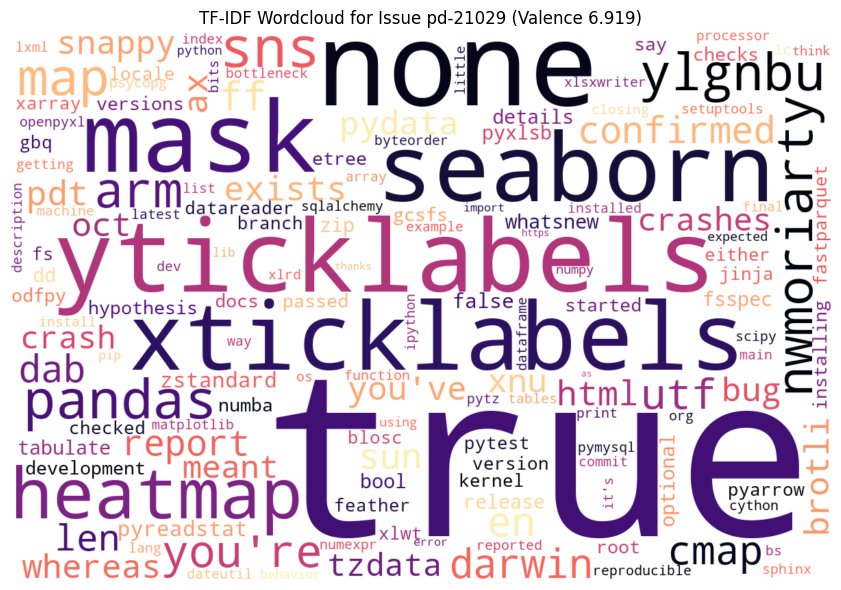


=== Top 2 Issue ===
Issue ID: tf-24225
Valence: 6.495

Issue text:
TF 2 libraries for Arduino IDE
@tensorflow/micro  The arduino library managers only provide tf 1.14 and 1.15 build-in libraries and hope tensorflow team could provide the tf 2 libraries for Arduino IDE. 

Valence score of top TF-IDF term 'arduino': N/A


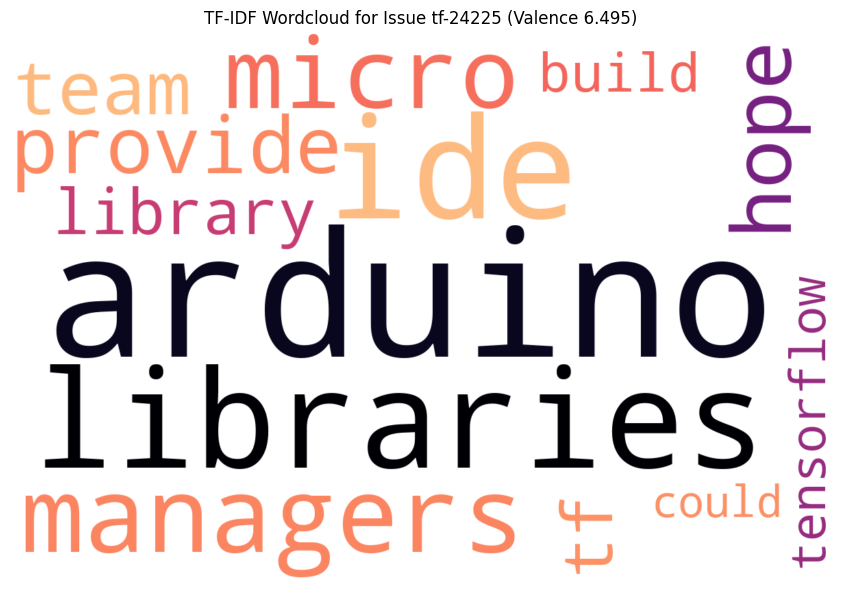


=== Top 3 Issue ===
Issue ID: pd-1389
Valence: 6.461

Issue text:
Odd unstack failure
Set day,time, smoker as index, unstack(2)  ``` day,time,smoker,sum,len Fri,Dinner,No,8.25,3 Fri,Dinner,Yes,27.03,9 Fri,Lunch,No,3.0,1 Fri,Lunch,Yes,13.68,6 Sat,Dinner,No,139.63,45 Sat,Dinner,Yes,120.77,42 Sun,Dinner,No,180.57,57 Sun,Dinner,Yes,66.82,19 Thur,Dinner,No,3.0,1 Thur,Lunch,No,117.32,44 Thur,Lunch,Yes,51.51,17 ```  

Valence score of top TF-IDF term 'dinner': 7.4


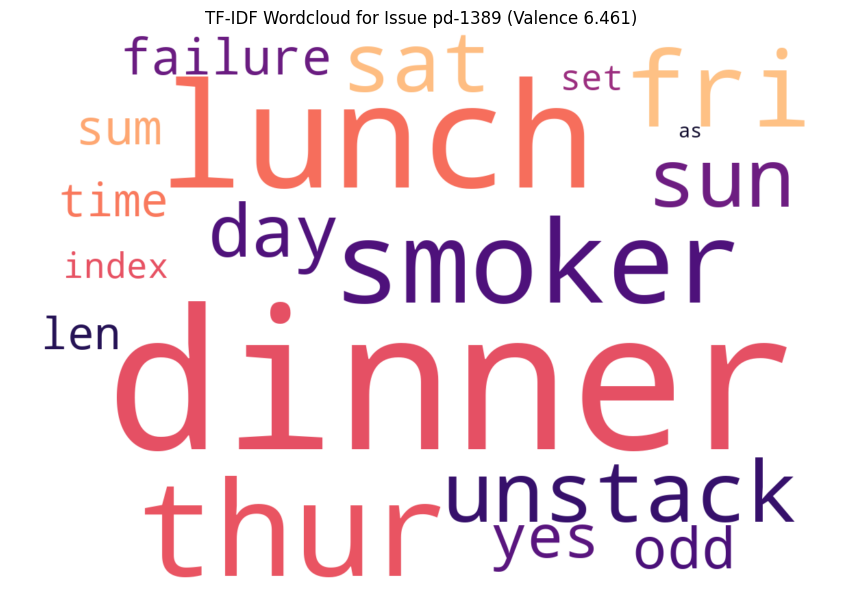


=== Top 4 Issue ===
Issue ID: pd-436
Valence: 6.286

Issue text:
read_csv performance regression
3x performance regression, likely b/c unicode changes  

Valence score of top TF-IDF term 'regression': N/A


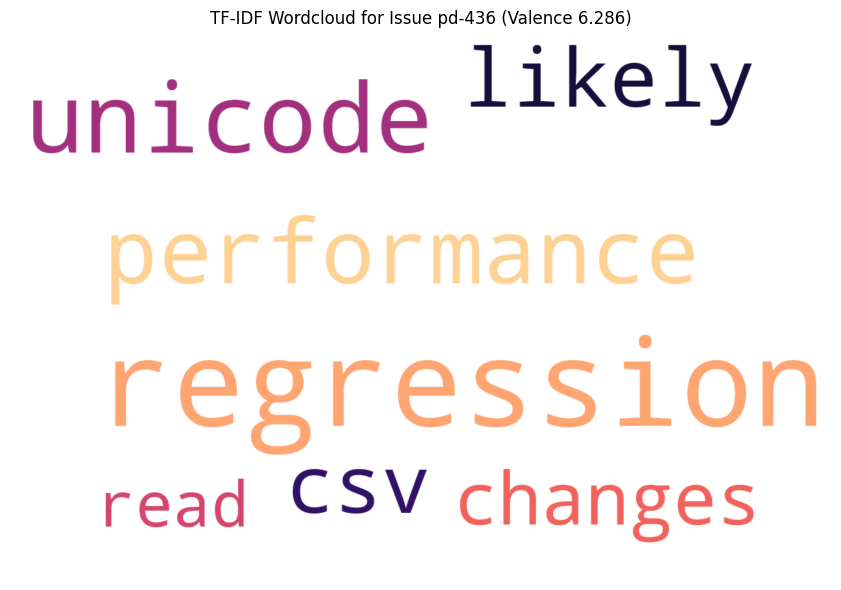


=== Top 5 Issue ===
Issue ID: tf-15015
Valence: 6.160

Issue text:
Any project about the evaluation of music or piano
Dear, Is there any project about evaluating the music or piano music, When we get many datasets of the same music from many people, How could we evaluate one of them,that is ,the label is the grad of the music is A ,B,C or D,  or just score between 0~100, Could we do something about this? Any advice or suggestion will be good. If U have any question,Please do not hesitate to tell me. Thx Probably you can take a look at [TensorFlow Magenta](https://magenta.tensorflow.org/). If you have specific questions related to Magenta project you can post it on [Magenta Github repo](https://github.com/tensorflow/magenta/issues). Thanks!

Valence score of top TF-IDF term 'music': 8.02


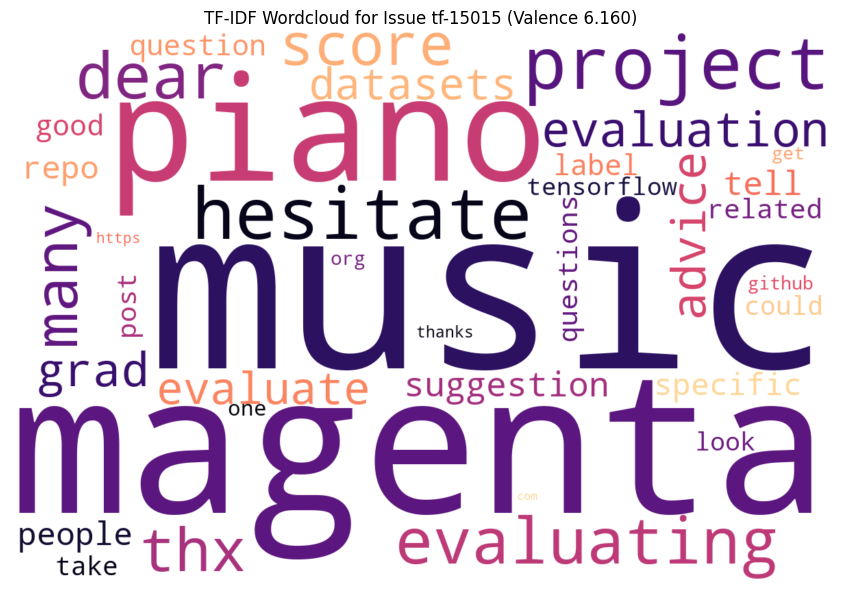

In [115]:
def plot_top_valence_issues_wordcloud(top5, all_df_processed, tfidf_per_issue, hedonometer_dict):
    for rank, (issue_id, val) in enumerate(top5.items(), start=1):
        print(f"\n=== Top {rank} Issue ===")
        print(f"Issue ID: {issue_id}")
        print(f"Valence: {val:.3f}")
        
        print("\nIssue text:")
        print(all_df_processed.loc[issue_id, "full_text"])
        
        best_tfidf = tfidf_per_issue.get(issue_id, {})
        
        if len(best_tfidf) > 0:
            top_word = max(best_tfidf, key=best_tfidf.get)
            top_word_val = hedonometer_dict.get(top_word, "N/A")
            print(f"\nValence score of top TF-IDF term '{top_word}': {top_word_val}")

        wc = WordCloud(width=1200, height=800, background_color="white",
            colormap="magma"
        ).generate_from_frequencies(best_tfidf)

        plt.figure(figsize=(10, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"TF-IDF Wordcloud for Issue {issue_id} (Valence {val:.3f})")
        plt.tight_layout()
        plt.show()

top5 = valence_series.dropna().nlargest(5)
plot_top_valence_issues_wordcloud(top5, all_df_processed, tfidf_per_issue, hedonometer_dict)

## Plotting the 5 issues with lowest sentiment


=== Top 1 Issue ===
Issue ID: tf-6842
Valence: 3.146

Issue text:
Tensorflow execution with HVX failed on Qualcomm 820 Board
@satok16 could you have a look at this error?   I have built the libs and am using Intrinsys 820 Qualcomm board. Tried your troubleshooting procedure to sign as well and put the .so file in `/system/lib/rfsa/adsp/`. Running hexagon graph gives me the same error :   ``` WARNING: linker: Warning: unable to normalize "" Running main() from test_main.cc Note: Google Test filter = GraphTransferer.RunInceptionV3OnHexagonExampleWithTfRuntime [==========] Running 1 test from 1 test case. [----------] Global test environment set-up. [----------] 1 test from GraphTransferer [ RUN      ] GraphTransferer.RunInceptionV3OnHexagonExampleWithTfRuntime native : hexagon_graph_execution_test.cc:445 Fuse and run inception v3 on hexagon with tf runtime tensorflow/core/kernels/hexagon/hexagon_graph_execution_test.cc:72: Failure Expected: (version) >= (1), actual: 0 vs 1 native : hexa

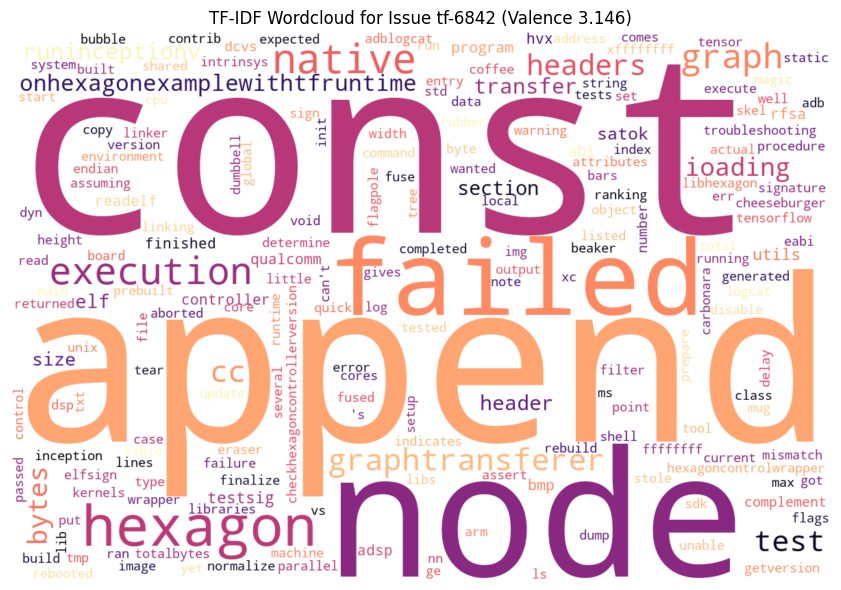


=== Top 2 Issue ===
Issue ID: tf-39347
Valence: 3.252

Issue text:
I am a spammer with no shame, I will spam your project
I am a spammer with no shame Why are you spamming?

Valence score of top TF-IDF term 'spammer': N/A


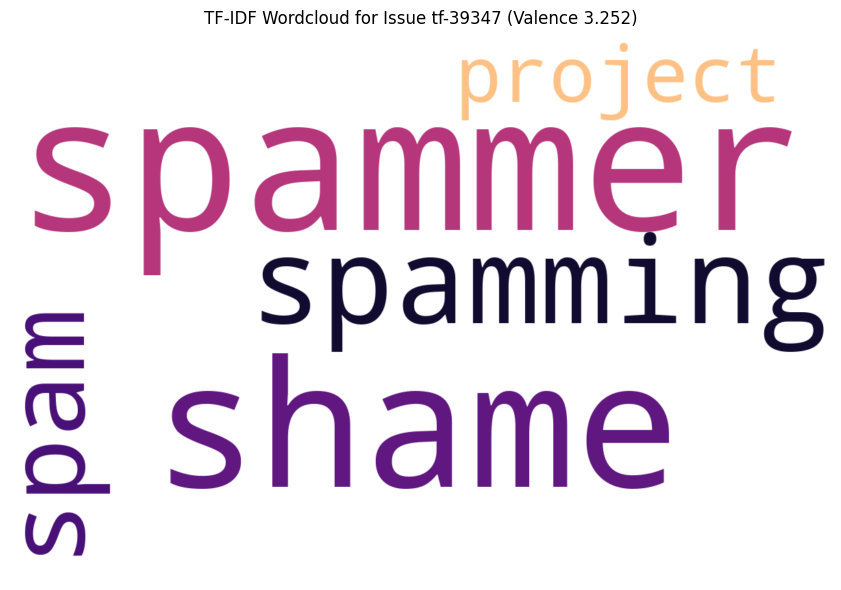


=== Top 3 Issue ===
Issue ID: pd-16499
Valence: 3.764

Issue text:
CI: Linux py36_locale failures with pytest DeprecationWarning
tests using `async_mark` are failing cc @alimcmaster1  ``` =========================== short test summary info ============================ ERROR pandas/tests/arrays/categorical/test_warnings.py::TestCategoricalWarnings ERROR pandas/tests/arrays/categorical/test_warnings.py::TestCategoricalWarnings ERROR pandas/tests/frame/test_api.py::TestDataFrameMisc - pytest.PytestDeprec... ERROR pandas/tests/frame/test_api.py::TestDataFrameMisc - pytest.PytestDeprec... ERROR pandas/tests/indexes/test_base.py::TestIndex - pytest.PytestDeprecation... ERROR pandas/tests/indexes/test_base.py::TestIndex - pytest.PytestDeprecation... ERROR pandas/tests/resample/test_resampler_grouper.py - pytest.PytestDeprecat... ERROR pandas/tests/resample/test_resampler_grouper.py - pytest.PytestDeprecat... ERROR pandas/tests/series/test_api.py::TestSeriesMisc - pytest.PytestDeprecat... ERR

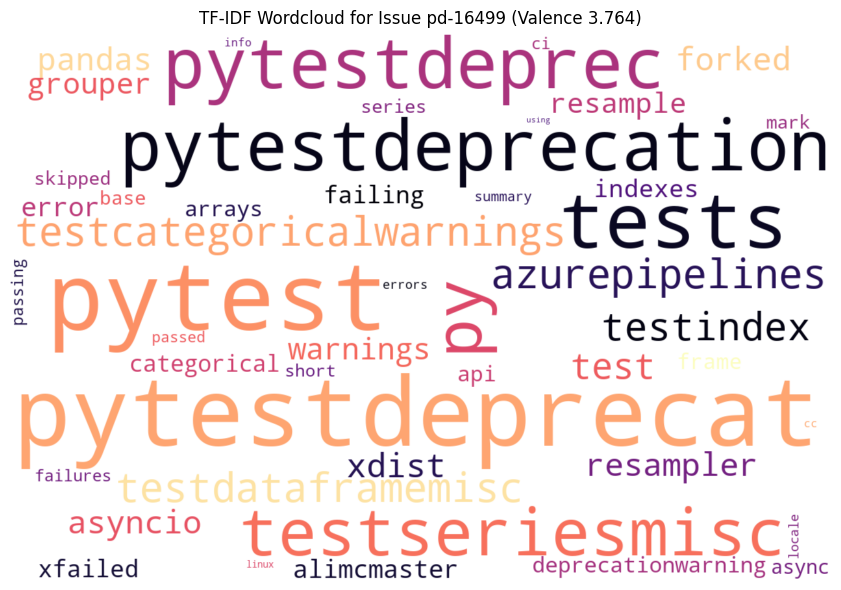


=== Top 4 Issue ===
Issue ID: pd-13128
Valence: 3.766

Issue text:
CI: Linting error
I'm working on #25424, after rebase to upstream/master, I get [linting errors](https://dev.azure.com/pandas-dev/pandas/_build/results?buildId=9370).  error F632,  E117 are simple fix. error F821 is type hints as flakes8 cannot detect buildin type.  I can fix as: a. add `#noqa` at the end line b. add build in option in setup.cfg ``` builtins =     _,     _LE,     _LW ```   ``` ##[error]./pandas/tests/indexes/interval/test_interval_tree.py(162,20): error F632: use ==/!= to compare str, bytes, and int literals ##[error]./pandas/tests/frame/test_alter_axes.py(204,32): error F632: use ==/!= to compare str, bytes, and int literals ##[error]./pandas/tests/frame/test_alter_axes.py(204,51): error F632: use ==/!= to compare str, bytes, and int literals ##[error]./pandas/tests/frame/test_alter_axes.py(1275,13): error E117: over-indented (comment) ##[error]./pandas/tests/io/test_pytables.py(2389,13): error E117: 

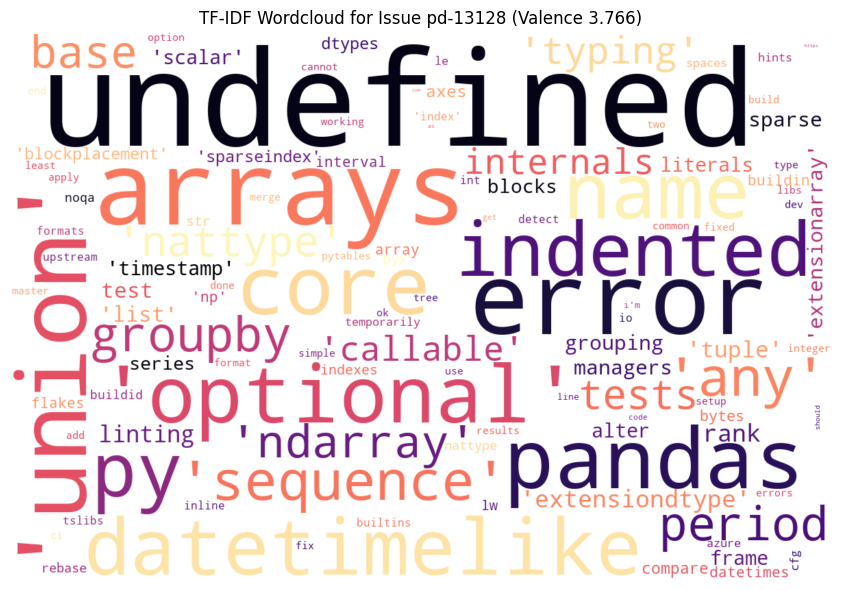


=== Top 5 Issue ===
Issue ID: pd-18788
Valence: 3.794

Issue text:
TST: Add doctests on cython files
Adding `--doctest-cython` to `ci/run_tests.sh` to cover doctests in cython files.  Lots of them are failing at the moment. But I think few of them (like now, today), can be skipped using `# doctest: +SKIP`.  Below is the current list of failures atm. ```python ===================================================================================== short test summary info ===================================================================================== FAILED pandas/_libs/hashtable.cpython-38-darwin.so::pandas._libs.hashtable.Int64Factorizer.factorize FAILED pandas/_libs/hashtable.cpython-38-darwin.so::pandas._libs.hashtable.ObjectFactorizer.factorize FAILED pandas/_libs/hashtable.cpython-38-darwin.so::pandas._libs.hashtable.__test__.Int64Factorizer.factorize (line 134) FAILED pandas/_libs/hashtable.cpython-38-darwin.so::pandas._libs.hashtable.__test__.ObjectFactorizer.factorize (line 

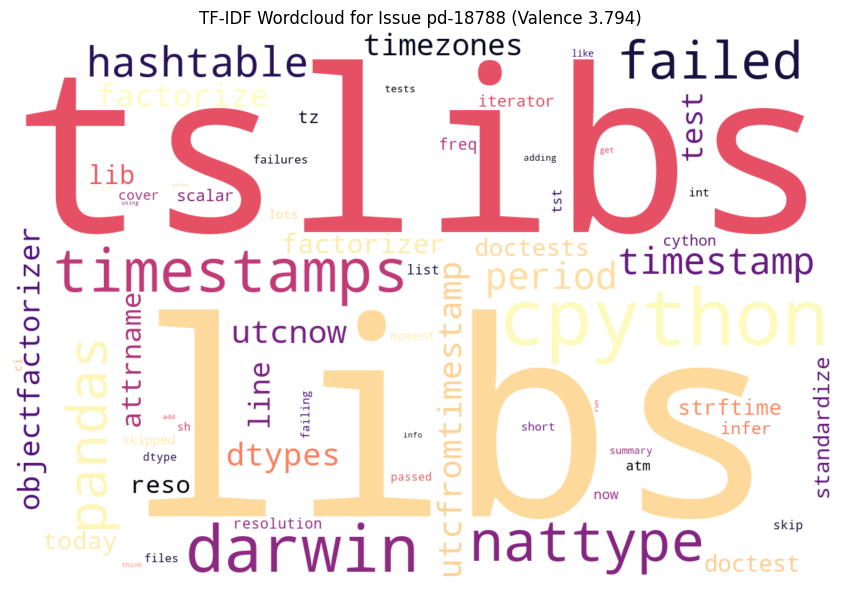

In [116]:
bottom5 = valence_series.dropna().nsmallest(5)
plot_top_valence_issues_wordcloud(bottom5, all_df_processed, tfidf_per_issue, hedonometer_dict)

## Compare Sentiment profiles per repository

Take average valence score per repo and compare to see which repo's are happier and which ones are sadder

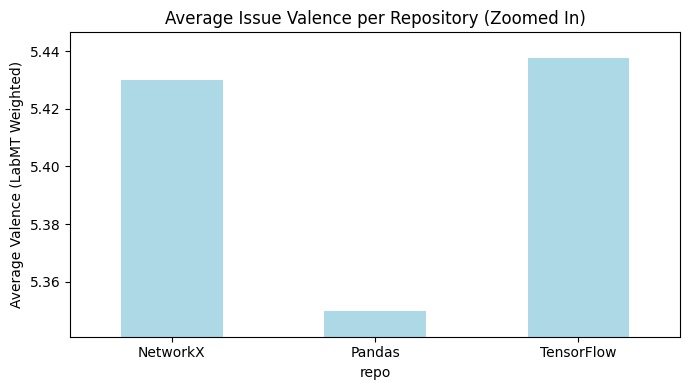

In [133]:
valence_df = pd.DataFrame(
    [(whatever, somevarorsumn) for whatever, somevarorsumn in issue_valence.items()],
    columns=["issue_id", "valence"]
)

valence_df["repo"] = valence_df["issue_id"].str[:2]

grouped = valence_df.groupby("repo")["valence"]

means = grouped.mean()
vars_ = grouped.var()
sizes = grouped.count()

grouped = valence_df.groupby("repo")["valence"]

vals_nx = grouped.get_group("nx").dropna().values
vals_pd = grouped.get_group("pd").dropna().values
vals_tf = grouped.get_group("tf").dropna().values

name_map = {
    "nx": "NetworkX",
    "pd": "Pandas",
    "tf": "TensorFlow"
}

avg_valence_named = means.rename(index=name_map)

min_val = avg_valence_named.min()
max_val = avg_valence_named.max()

padding = (max_val - min_val) * 0.1

plt.figure(figsize=(7,4))
avg_valence_named.plot(kind="bar", color="lightblue")

plt.ylabel("Average Valence (LabMT Weighted)")
plt.title("Average Issue Valence per Repository (Zoomed In)")
plt.xticks(rotation=0)

plt.ylim(min_val - padding, max_val + padding)

plt.tight_layout()
plt.show()

#### A Difference?


We see a very clear difference in Average Valence values between Pandas and NetworkX and TensorFlow, however do these values mean anything? To prove this we will calculate the P-values

In [143]:
print("Means:\n", means)
print("Variances:\n", vars_)
print("Sizes:\n", sizes)

pvals = {}

# nx vs pd
t_stat, p_val = ttest_ind(vals_nx, vals_pd, equal_var=False, nan_policy="omit")
pvals[("nx", "pd")] = (t_stat, p_val)

# nx vs tf
t_stat, p_val = ttest_ind(vals_nx, vals_tf, equal_var=False, nan_policy="omit")
pvals[("nx", "tf")] = (t_stat, p_val)

# pd vs tf
t_stat, p_val = ttest_ind(vals_pd, vals_tf, equal_var=False, nan_policy="omit")
pvals[("pd", "tf")] = (t_stat, p_val)

print("Pairwise Welch t-test results:")
for (a, b), (t_stat, p_val) in pvals.items():
    print(f"{a} vs {b}: t = {t_stat:.4f}, p = {p_val:.6g}")

Means:
 repo
nx    5.429934
pd    5.349723
tf    5.437759
Name: valence, dtype: float64
Variances:
 repo
nx    0.027824
pd    0.030009
tf    0.019869
Name: valence, dtype: float64
Sizes:
 repo
nx     3130
pd    23629
tf    39426
Name: valence, dtype: int64
Pairwise Welch t-test results:
nx vs pd: t = 25.1654, p = 5.07142e-130
nx vs tf: t = -2.5532, p = 0.0107165
pd vs tf: t = -66.0985, p = 0


Comparing NetworkX to Tensorflow gives relatively low t-statistic and relatively high p-value, this is due to the differences between dataset sizes, and relatively small difference in actual means. Comparing NetworkX to pandas and Pandas to Tensorflow however gives high t-statistics and extremely low p-values, showing actual statistical meaning in the differences between the means.

## Compare TF-IDF profiles per repository

Aggregate TF-IDF scores per repo and inspect which terms are most characteristic for each repository.

In [118]:
repo_term_scores = defaultdict(lambda: defaultdict(float))

for issue_id, tfidf in tfidf_per_issue.items():
    repo = all_df_processed.loc[issue_id, "repo_name"]
    for term, score in tfidf.items():
        repo_term_scores[repo][term] += score

repo_top_terms = {}
for repo, term_scores in repo_term_scores.items():
    ranked = sorted(term_scores.items(), key=lambda kv: kv[1], reverse=True)[:50]
    repo_top_terms[repo] = ranked

## Visualize top TF-IDF terms per repository

Plot bar charts of the most characteristic terms for a few selected repositories.

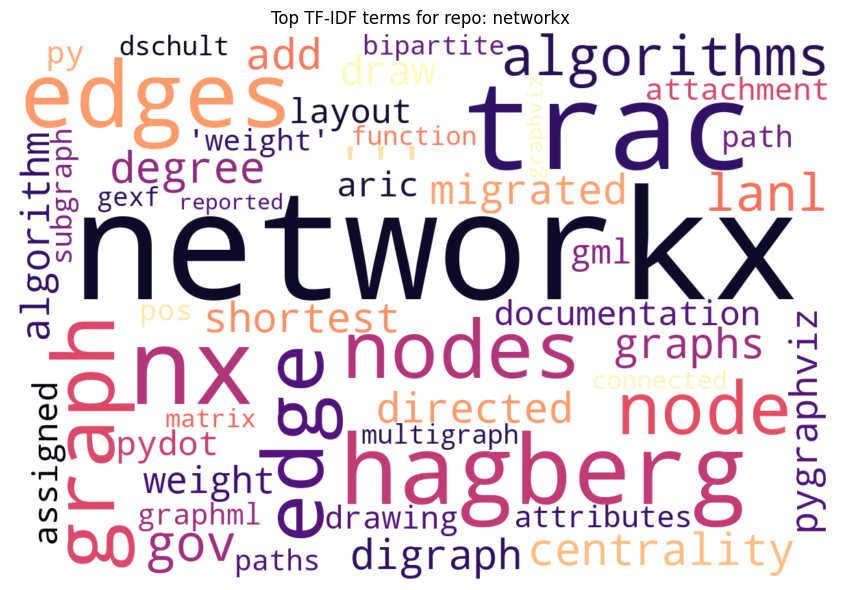

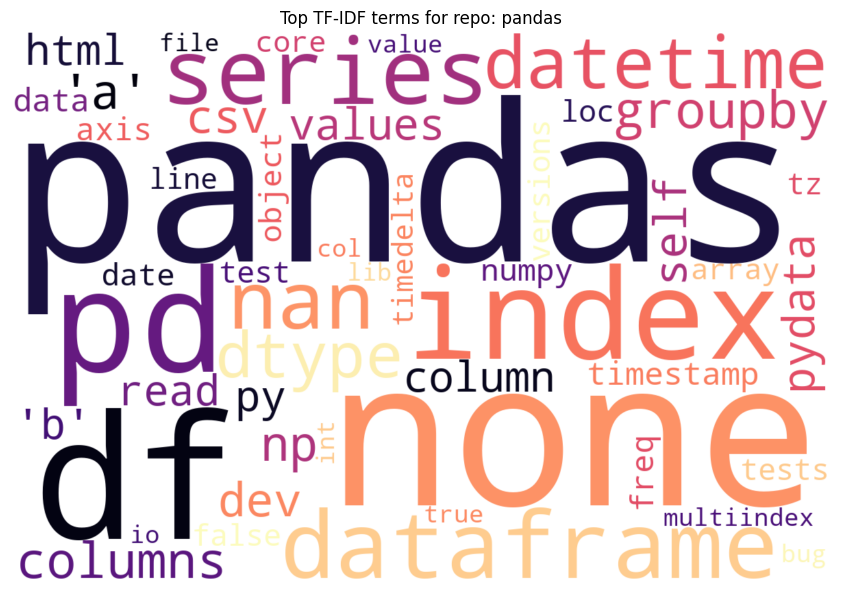

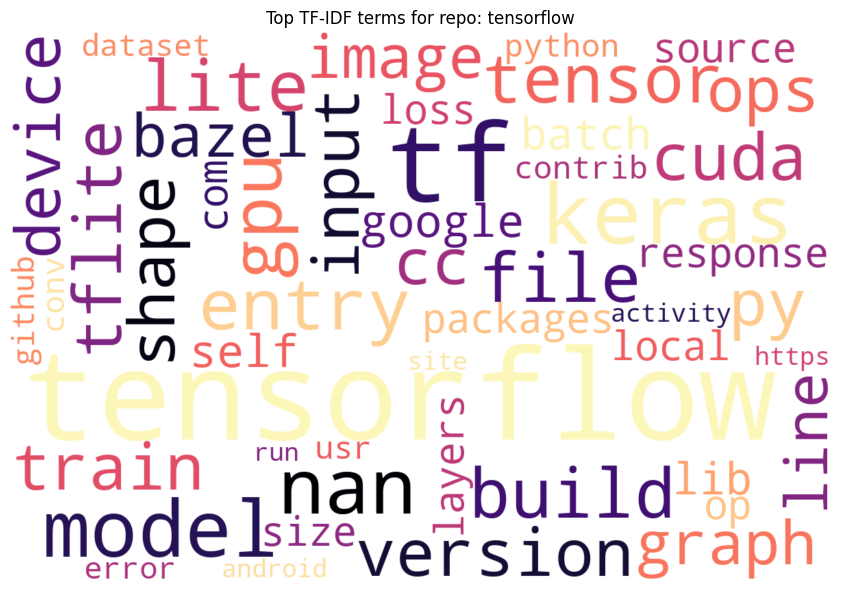

In [119]:
repos_to_plot = list(repo_top_terms.keys())

for repo in repos_to_plot:
    ranked = repo_top_terms[repo]

    freq_dict = dict(ranked)

    wc = WordCloud(
        width=1200,
        height=800,
        background_color="white",
        colormap="magma" # i rlly like the magma theme :)
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Top TF-IDF terms for repo: {repo}")
    plt.tight_layout()
    plt.show()
